# This file for understanding the Data

## Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

## Data

In [4]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

print(f'Cap data: {cap_data.shape[0]} days, maturities: {list(cap_data.columns)}')
print(f'Date range: {cap_data.index.min().date()} to {cap_data.index.max().date()}')
cap_data.tail(3)

Cap data: 989 days, maturities: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Date range: 2022-03-17 to 2025-12-31


maturity,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
date,,,,,,,,,,
2025-12-29,52.2,66.8,73.5,77.3,79.6,81.2,82.1,82.8,83.3,83.7
2025-12-30,50.9,66.1,72.9,76.7,78.9,80.4,81.3,81.9,82.4,82.8
2025-12-31,50.8,65.9,72.9,76.7,78.9,80.4,81.4,82.0,NaN,NaN


In [18]:
# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

print(f'SOFR swap data: {sofr_data.shape[0]} days, {sofr_data.shape[1]} tenors')
sofr_data.tail(3)

SOFR swap data: 1033 days, 21 tenors


maturity,0.25,0.50,0.75,1.00,1.25,1.50,1.75,...,4.50,5.00,6.00,7.00,8.00,9.00,10.00
date,,,,,,,,,,,,,,,
2025-12-29,0.036670,0.035886,0.034989,0.034239,0.033538,0.033140,0.032940,...,0.033746,0.034104,0.034800,0.035506,0.036177,0.036827,0.037457
2025-12-30,0.036567,0.035805,0.034931,0.034190,0.033510,0.033115,0.032919,...,0.033849,0.034214,0.034927,0.035648,0.036330,0.036989,0.037621
2025-12-31,0.036517,0.035796,0.034961,0.034270,0.033631,0.033285,0.033140,...,0.034226,0.034638,0.035355,0.036068,0.036735,0.037388,0.038023


In [7]:
# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100
print(f'SOFR daily: {len(sofr_daily)} observations, {sofr_daily.index.min().date()} to {sofr_daily.index.max().date()}')
sofr_daily.head(5)

SOFR daily: 1935 observations, 2018-04-03 to 2025-12-31


date
2018-04-03    0.0183
2018-04-04    0.0174
2018-04-05    0.0175
2018-04-06    0.0175
2018-04-09    0.0175
Name: SOFR, dtype: float64

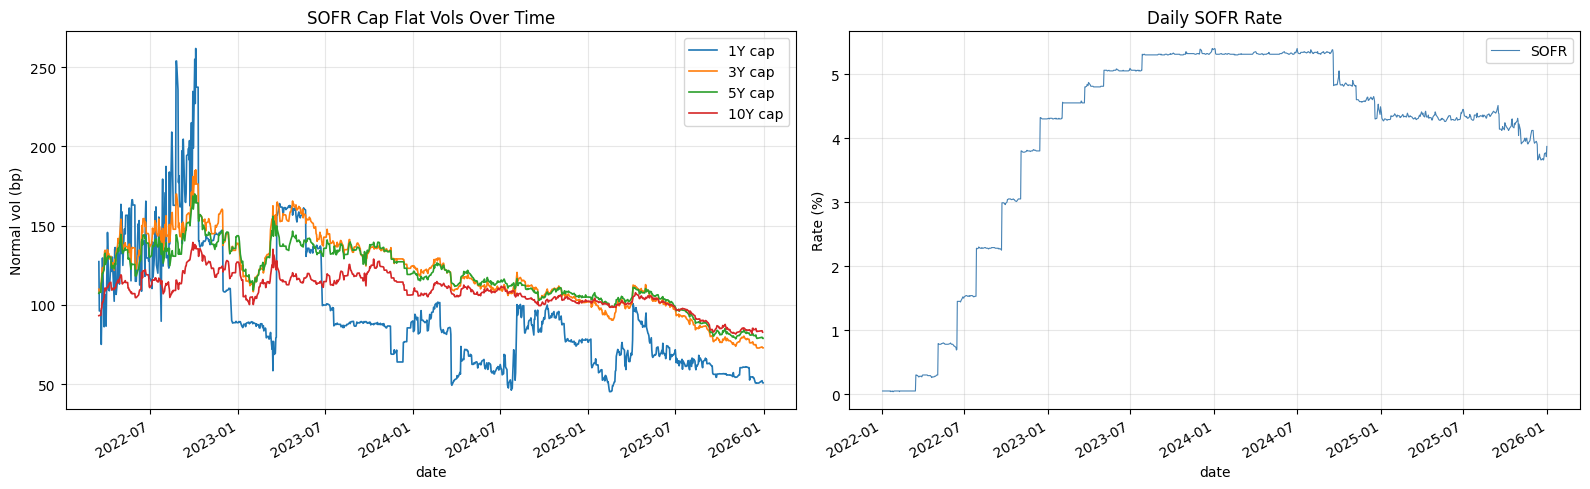

In [10]:
# Figure 1: Cap flat vols over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for mat in [1.0, 3.0, 5.0, 10.0]:
    if mat in cap_data.columns:
        cap_data[mat].dropna().plot(ax=ax, label=f'{int(mat)}Y cap', linewidth=1.2)
ax.set_ylabel('Normal vol (bp)')
ax.set_title('SOFR Cap Flat Vols Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# SOFR rate for context
ax = axes[1]
sofr_rate_pct = sofr_daily.loc['2022':] * 100
sofr_rate_pct.plot(ax=ax, linewidth=0.8, color='steelblue', label='SOFR')
ax.set_ylabel('Rate (%)')
ax.set_title('Daily SOFR Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()